# Практическая 7-8 (Саттаров Булат Рамилевич ЭФМО-01-25)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Загрузка данных

Используется датасет `winequality-red.csv` из третьей практической работы. Последний столбец `quality` содержит исходную оценку качества вина.

In [3]:
df = pd.read_csv('winequality-red.csv')

# В некоторых версиях файла разделителем может быть ';'. Проверим и при необходимости перечитаем файл.
if df.shape[1] == 1:
    df = pd.read_csv('winequality-red.csv', sep=';')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
print('Размер данных:', df.shape)
df.info()

Размер данных: (1599, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Формирование двух классов

По условию работы:

* `0` — первый класс, качество `quality <= 5`;
* `1` — второй класс, качество `quality > 5`.

In [6]:
data = df.copy()
data['target'] = np.where(data['quality'] <= 5, 0, 1)

target_names = {
    0: 'Класс 1: quality <= 5',
    1: 'Класс 2: quality > 5'
}

data[['quality', 'target']].head(10)

,quality,target
0,5,0
1,5,0
2,5,0
3,6,1
4,5,0
5,5,0
6,5,0
7,7,1
8,7,1
9,5,0


target
Класс 1: quality <= 5    744
Класс 2: quality > 5     855
Name: count, dtype: int64


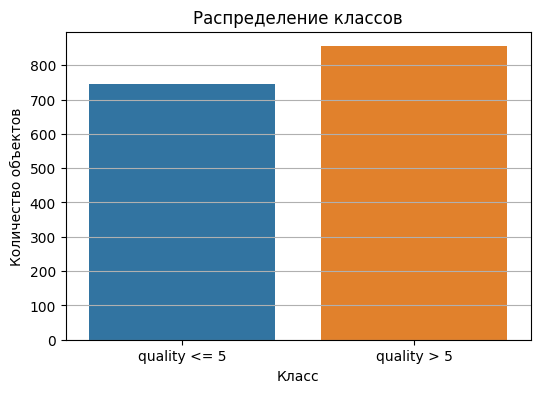

In [7]:
class_counts = data['target'].value_counts().sort_index()
print(class_counts.rename(index=target_names))

plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='target', hue='target', palette='tab10', legend=False)
plt.xticks([0, 1], ['quality <= 5', 'quality > 5'])
plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.grid(axis='y')
plt.show()

Распределение классов не идеально равномерное, поэтому кроме `accuracy` дополнительно будем смотреть `precision`, `recall`, `f1-score` и матрицу путаницы.

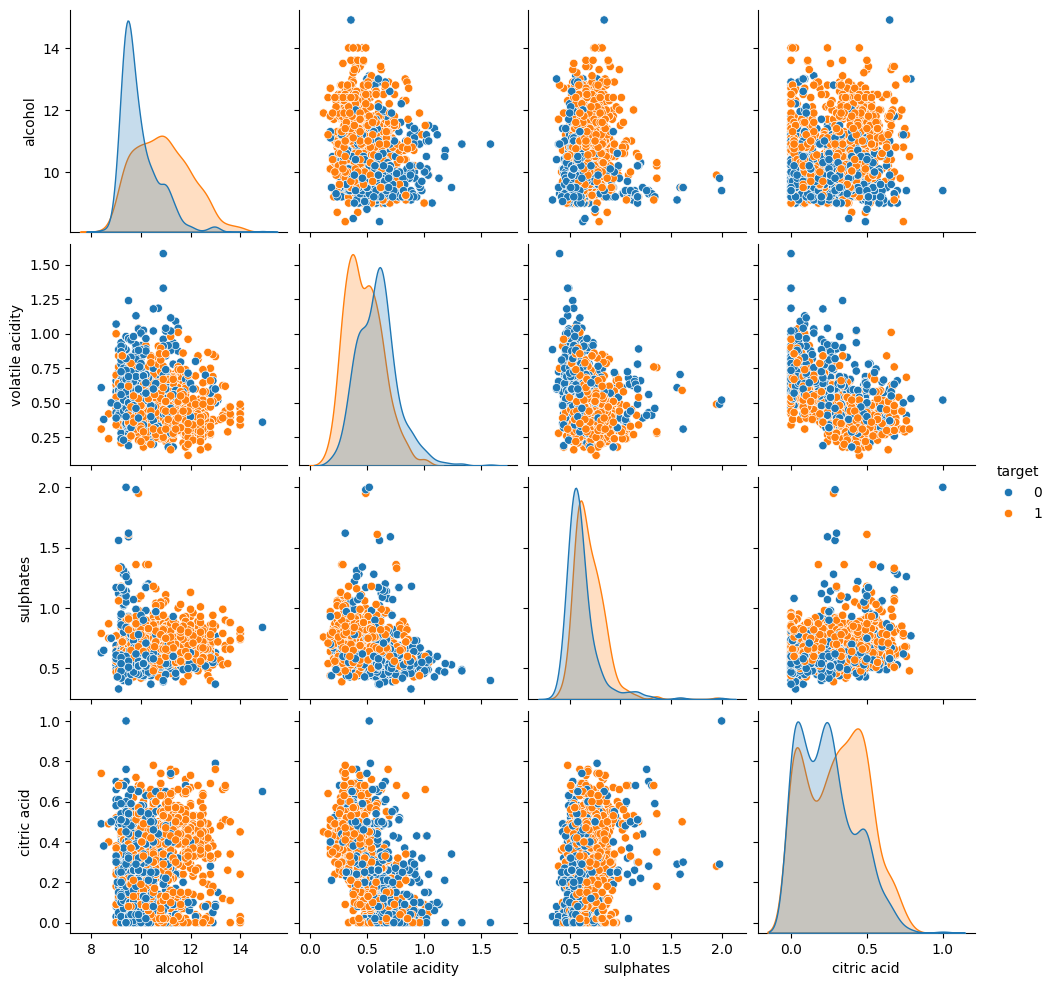

In [8]:
plot_columns = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'target']
sns.pairplot(data[plot_columns], hue='target', palette='tab10')
plt.show()

## Подготовка обучающей и тестовой выборок

Признак `quality` убирается из входных данных, потому что по нему уже сформирован целевой класс.

In [9]:
X = data.drop(columns=['quality', 'target'])
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

X_train_t.shape, y_train_t.shape, X_test_t.shape, y_test_t.shape

(torch.Size([1279, 11]),
 torch.Size([1279, 1]),
 torch.Size([320, 11]),
 torch.Size([320, 1]))

## Создание нейронной сети

Соберем многослойный персептрон средствами `PyTorch`. На выходе один нейрон с `Sigmoid`, так как задача бинарной классификации.

In [10]:
class WinePerceptron(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

model = WinePerceptron(input_dim=X_train_t.shape[1])
model

WinePerceptron(
  (layers): Sequential(
    (0): Linear(in_features=11, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
    (6): Sigmoid()
  )
)

## Обучение модели

В качестве функции потерь используется бинарная кросс-энтропия, оптимизатор — `Adam`.

In [11]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 300
history = []

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0 or epoch == 1:
        with torch.no_grad():
            train_proba = model(X_train_t).numpy().reshape(-1)
            train_pred = (train_proba >= 0.5).astype(int)
            train_acc = accuracy_score(y_train, train_pred)
            history.append({'epoch': epoch, 'loss': float(loss), 'accuracy': train_acc})

history_df = pd.DataFrame(history)
history_df.tail()

,epoch,loss,accuracy
26,260,0.310412,0.854574
27,270,0.302782,0.864738
28,280,0.308002,0.870211
29,290,0.297626,0.869429
30,300,0.302201,0.869429


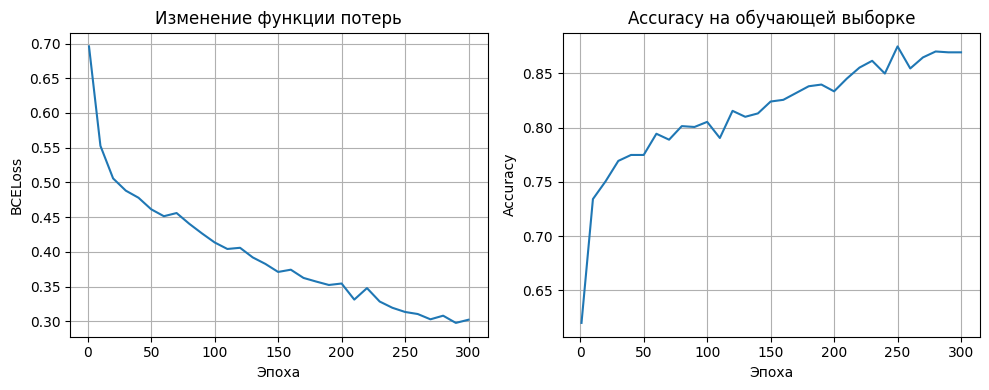

In [12]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['loss'])
plt.title('Изменение функции потерь')
plt.xlabel('Эпоха')
plt.ylabel('BCELoss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['accuracy'])
plt.title('Accuracy на обучающей выборке')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

## Оценка качества нейронной сети

In [13]:
model.eval()
with torch.no_grad():
    proba_test = model(X_test_t).numpy().reshape(-1)

pred_test = (proba_test >= 0.5).astype(int)

nn_accuracy = accuracy_score(y_test, pred_test)
nn_f1 = f1_score(y_test, pred_test)
nn_auc = roc_auc_score(y_test, proba_test)

print('Accuracy:', round(nn_accuracy, 4))
print('F1-score:', round(nn_f1, 4))
print('AUC ROC:', round(nn_auc, 4))
print()
print(classification_report(y_test, pred_test, target_names=list(target_names.values())))

Accuracy: 0.7937
F1-score: 0.8047
AUC ROC: 0.8706

                       precision    recall  f1-score   support

Класс 1: quality <= 5       0.77      0.79      0.78       149
 Класс 2: quality > 5       0.81      0.80      0.80       171

             accuracy                           0.79       320
            macro avg       0.79      0.79      0.79       320
         weighted avg       0.79      0.79      0.79       320



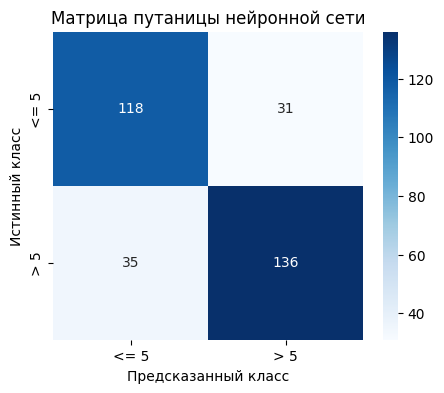

In [14]:
def display_confusion_matrix(matrix, labels, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')
    plt.show()

matrix_nn = confusion_matrix(y_test, pred_test)
display_confusion_matrix(matrix_nn, ['<= 5', '> 5'], 'Матрица путаницы нейронной сети')

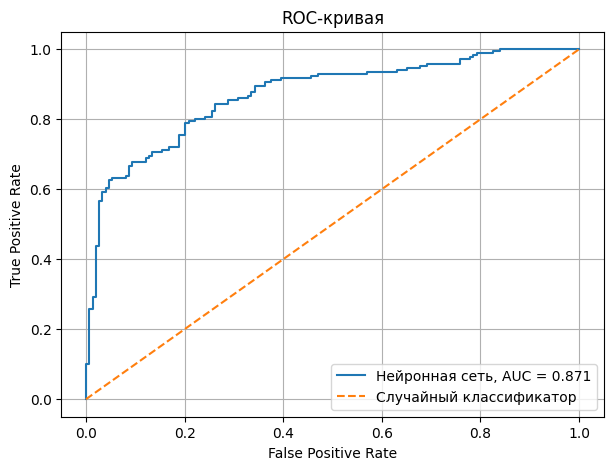

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, proba_test)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Нейронная сеть, AUC = {nn_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', label='Случайный классификатор')
plt.title('ROC-кривая')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

## Сравнение с третьей работой

В третьей практической работе использовался метод `kNN`. Для корректного сравнения на текущем разбиении классов обучим kNN на той же обучающей и тестовой выборках.  
Дополнительно отметим, что в третьей работе использовался другой критерий выделения класса качества (`quality >= 7`), поэтому абсолютное совпадение метрик с той работой не ожидается.

In [16]:
knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_proba = knn.predict_proba(X_test)[:, 1]

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)
knn_auc = roc_auc_score(y_test, knn_proba)

print('Accuracy:', round(knn_accuracy, 4))
print('F1-score:', round(knn_f1, 4))
print('AUC ROC:', round(knn_auc, 4))
print()
print(classification_report(y_test, knn_pred, target_names=list(target_names.values())))

Accuracy: 0.7406
F1-score: 0.7566
AUC ROC: 0.8117

                       precision    recall  f1-score   support

Класс 1: quality <= 5       0.72      0.72      0.72       149
 Класс 2: quality > 5       0.76      0.75      0.76       171

             accuracy                           0.74       320
            macro avg       0.74      0.74      0.74       320
         weighted avg       0.74      0.74      0.74       320



In [17]:
comparison = pd.DataFrame({
    'Метод': ['Нейронная сеть', 'kNN из третьей работы'],
    'Accuracy': [nn_accuracy, knn_accuracy],
    'F1-score': [nn_f1, knn_f1],
    'AUC ROC': [nn_auc, knn_auc]
})

comparison

,Метод,Accuracy,F1-score,AUC ROC
0,Нейронная сеть,0.793750,0.804734,0.870599
1,kNN из третьей работы,0.740625,0.756598,0.811708


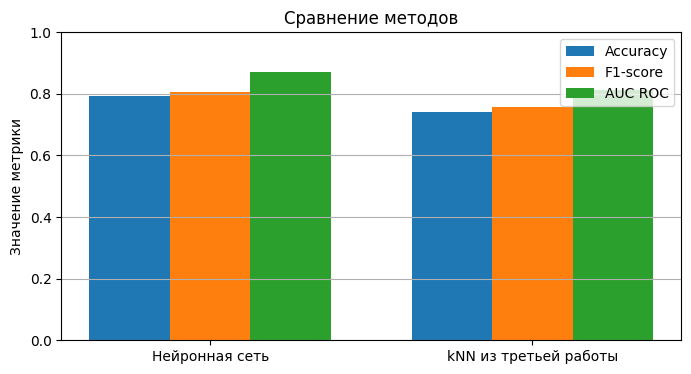

In [18]:
plt.figure(figsize=(8, 4))
x = np.arange(len(comparison['Метод']))
width = 0.25

plt.bar(x - width, comparison['Accuracy'], width, label='Accuracy')
plt.bar(x, comparison['F1-score'], width, label='F1-score')
plt.bar(x + width, comparison['AUC ROC'], width, label='AUC ROC')

plt.xticks(x, comparison['Метод'])
plt.ylim(0, 1)
plt.title('Сравнение методов')
plt.ylabel('Значение метрики')
plt.legend()
plt.grid(axis='y')
plt.show()

## Проверка работы модели на одном объекте

Обученная нейронная сеть может принимать значения признаков вина и выдавать вероятность принадлежности ко второму классу (`quality > 5`).

In [19]:
def predict_wine_quality(features):
    features_df = pd.DataFrame([features], columns=X.columns)
    features_scaled = scaler.transform(features_df)
    features_t = torch.tensor(features_scaled, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        probability = model(features_t).item()

    predicted_class = int(probability >= 0.5)
    print('Вероятность класса quality > 5:', round(probability, 4))
    print('Предсказанный класс:', target_names[predicted_class])
    return predicted_class

example = X_test.iloc[0].to_dict()
print('Истинный класс:', target_names[int(y_test.iloc[0])])
predict_wine_quality(example)

Истинный класс: Класс 2: quality > 5
Вероятность класса quality > 5: 0.2233
Предсказанный класс: Класс 1: quality <= 5


0

## Вывод

В работе была обучена нейронная сеть для классификации красного вина по качеству. Исходная задача была сведена к бинарной классификации: вина с `quality <= 5` относятся к первому классу, а вина с `quality > 5` — ко второму.

Модель была построена как многослойный персептрон с двумя скрытыми слоями. По графику обучения видно, что функция потерь уменьшается, а качество на обучающей выборке растет. На тестовой выборке были рассчитаны основные показатели: `accuracy`, `F1-score`, `AUC ROC`, `precision`, `recall`, а также построены матрица путаницы и ROC-кривая.

Для сравнения был обучен kNN-классификатор, который использовался в третьей работе. При текущем разбиении классов нейронная сеть показывает сопоставимый результат с kNN. Важно учитывать, что в третьей работе классы выделялись иначе (`quality >= 7`), поэтому прямое сравнение чисел из прошлой работы и текущей практики не полностью корректно. Корректное сравнение внутри этой работы выполнено на одинаковом разбиении данных и одинаковой целевой переменной.